# Steane Basic Level Noise (single round)

Data generation and analysis
    + different decoder: ML, MWPM
    + different distances
    + different noise levels

analysis: 
    + show asymptotic behavior
    + determine thresholds


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tools.file import read_config, write_config, read_folder, get_standard_config
from tools.combined import generate_new_data_from_config_file
from tools.analysis import data_pre_processing, determine_threshold, data_plot_log_error_rates, data_plot_fssa_results

from tools.parameter import PATH_TO_CONFIG_FOLDER

## Config Defintions and Data Generation

Steane circ (order 0p) with only 1 QEC round (both log X and Z observable)

Basic noise with different noise levels

Decoding both in ML and MWPM


In [19]:
# General parameter
noise_rates = [float(x) for x in np.logspace(-1.2,-0.8,dtype=float)] # weird choice of noise rate because i need to put it into a yaml file -> might be probelmatic later!
distances = [3,5,7,9,11,13,15] # 3 is newly included! not yet in data!
qec_rounds = [1,]
order = "0p"
circuit_type = "steane"

# Main parameters
num_shots_ML = 10_000
decoder_type_ML = "ml"
# 30 min
# 700 min + for 100_000 data
num_shots_MWPM = 100_000
decoder_type_MWPM = "mwpm"

# Z config
noise_model_type_Z = "bit_flip"
observable_Z  = "Z"
init_state_Z = "0"
# X config
noise_model_type_X = "phase_flip"
observable_X  = "X"
init_state_X = "p"

In [20]:
# Folder names (for writing data to file):
w_folder_name_ML_Z = "basic_md_1r_steane_Z_ML"
w_folder_name_ML_X = "basic_md_1r_steane_X_ML"
w_folder_name_MWPM_Z = "basic_md_1r_steane_Z_MWPM"
w_folder_name_MWPM_X = "basic_md_1r_steane_X_MWPM"

In [21]:
# Switches for data generation
regen_data_everything = False 

regen_data_ML = False 
regen_data_MWPM = False 


In [22]:
# ML Config (Z)
# Verbose is better!
config_ML_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type_Z,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}
        
# write config to file
write_config(config_ML_Z,w_folder_name_ML_Z,backup=True)

In [23]:
# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_ML_Z + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_ML_Z)

In [24]:
# ML Config (X)

config_ML_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type_X,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}

# write config to file
write_config(config_ML_X,w_folder_name_ML_X,backup=True)

In [25]:
# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_ML_X + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_ML_X)

In [26]:
# MWPM Config (Z)

config_MWPM_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type_Z,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,       # number of shots per configuration
    },
}

# write config to file
write_config(config_MWPM_Z,w_folder_name_MWPM_Z,backup=True)

In [27]:
# Generate MWPM data
if regen_data_everything or regen_data_MWPM or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_MWPM_Z + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_MWPM_Z)

In [28]:
# MWPM Config (X)

config_MWPM_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type_X,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,     
    },
}

# write config to file
write_config(config_MWPM_X,w_folder_name_MWPM_X,backup=True)

In [29]:
# Generate MWPM data
if regen_data_everything or regen_data_MWPM or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_MWPM_X + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_MWPM_X)

## Analysis

[toric code](https://errorcorrectionzoo.org/c/toric):

+ toric code: code capacity 
    + MWPM: px = 10.31%
    + ML: 10.94 +- 0.02%

[surface code](https://errorcorrectionzoo.org/c/surface):

[arthur pesah](https://arthurpesah.me/blog/2023-05-13-surface-code/):





In [30]:
# Folder paths (reading in data)
r_folder_name_ML_Z = "basic_md_1r_steane_Z_ML_lots"
r_folder_name_ML_X = "basic_md_1r_steane_X_ML"
r_folder_name_MWPM_Z = "basic_md_1r_steane_Z_MWPM"
r_folder_name_MWPM_X = "basic_md_1r_steane_X_MWPM"

lit_p_th_ml = 0.1094
lit_p_th_mwpm = 0.1031

In [31]:
def analysis_pipeline(
        folder_name, 
        guess_pth, 
        guess_nu, 
        min_distance: list = None, 
        max_distance: list = None, 
        min_noise_rate: list = None,
        max_noise_rate: list = None,
        p_window: list = None,
        plots = True,
        ):

    if p_window != None:
        if min_noise_rate != None or max_noise_rate != None:
            raise UserWarning("Both p_window and min-/max_noise_rate give! Too much restictions!")
        min_noise_rate = np.array(guess_pth) / p_window,
        max_noise_rate = np.array(guess_pth) * p_window,

    print(min_noise_rate)
    print(max_noise_rate)
    config, data = read_folder(folder_name)
    data = data_pre_processing(data)
    data = determine_threshold(
        data,
        guess_nu=guess_nu,
        guess_pth=guess_pth,
        min_distance=min_distance,
        max_distance=max_distance,
        min_noise_rate=min_noise_rate,
        max_noise_rate=max_noise_rate,
        )
    # complete
    if plots:
        data_plot_log_error_rates(data)
        data_plot_fssa_results(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
            )
        # around threshold
        data_plot_log_error_rates(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
        )
    return data

### Generate analysis Data

In [32]:
# General fit parameters: 
g_pth_ml = 0.108
g_pth_mwpm = 0.103

g_nu = 1.5

p_window = [10**(0.1)]
min_distance = [5]

(array([0.08578745]),)
(array([0.13596394]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.8776789692636826
             x: [ 1.084e-01  6.535e-01]
           nit: 45
          nfev: 81
 final_simplex: (array([[ 1.084e-01,  6.535e-01],
                       [ 1.084e-01,  6.535e-01],
                       [ 1.084e-01,  6.535e-01]]), array([ 8.777e-01,  8.777e-01,  8.777e-01]))
[0.10836804]
[0.0008379]


<Figure size 640x480 with 0 Axes>

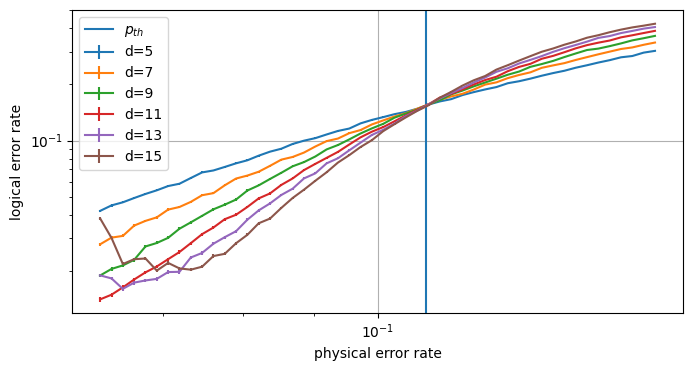

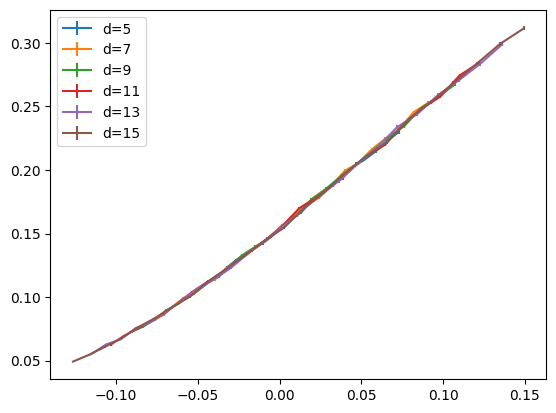

<Figure size 640x480 with 0 Axes>

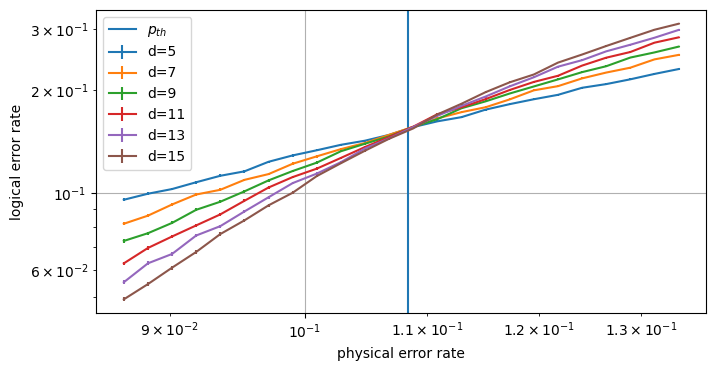

[0.10836804]
[1.53018037]


In [33]:
folder_name = r_folder_name_ML_Z
g_pth = g_pth_ml

result = analysis_pipeline(
    folder_name,
    guess_pth = [g_pth],
    guess_nu = [g_nu],
    min_distance= min_distance, 
    p_window = p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_ML_Z = result

(array([0.08578745]),)
(array([0.13596394]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.9237856617967195
             x: [ 1.075e-01  6.562e-01]
           nit: 51
          nfev: 101
 final_simplex: (array([[ 1.075e-01,  6.562e-01],
                       [ 1.075e-01,  6.562e-01],
                       [ 1.075e-01,  6.562e-01]]), array([ 9.238e-01,  9.238e-01,  9.238e-01]))
[0.10747862]
[0.00356708]


<Figure size 640x480 with 0 Axes>

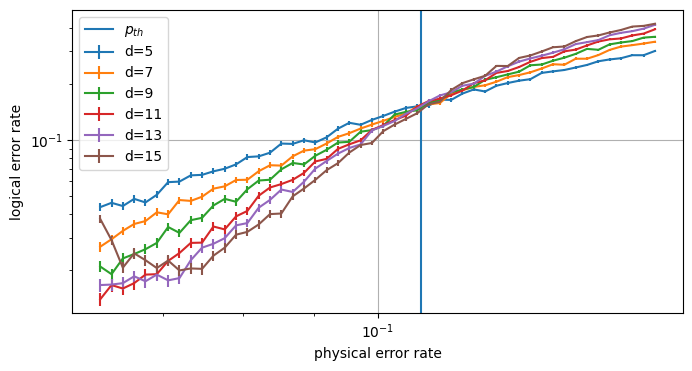

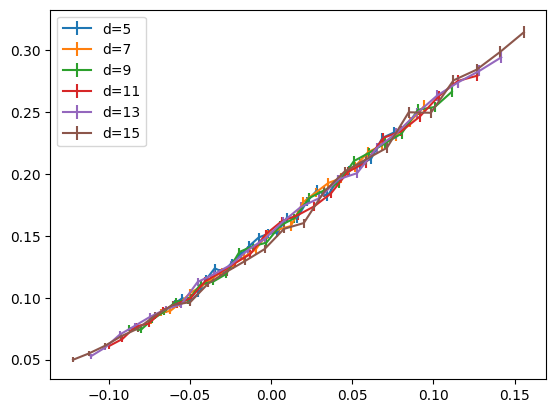

<Figure size 640x480 with 0 Axes>

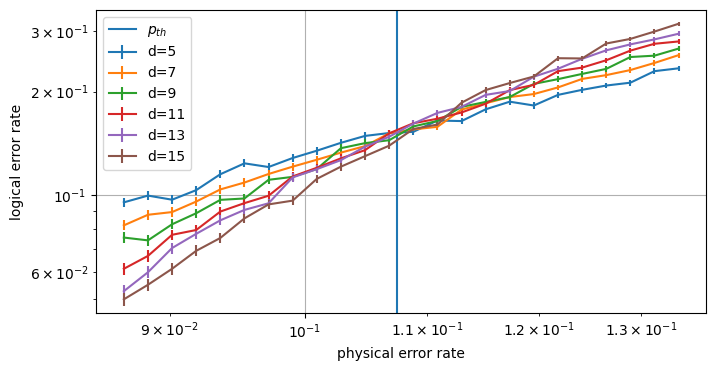

[0.10747862]
[1.52395301]


In [34]:
folder_name = r_folder_name_ML_X 
g_pth = g_pth_ml 

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = [g_pth],
    guess_nu = [g_nu],
    min_distance= min_distance, 
    p_window = p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_ML_X = result

(array([0.08181581]),)
(array([0.12966932]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.1842023413957243
             x: [ 1.022e-01  6.822e-01]
           nit: 39
          nfev: 78
 final_simplex: (array([[ 1.022e-01,  6.822e-01],
                       [ 1.022e-01,  6.822e-01],
                       [ 1.022e-01,  6.822e-01]]), array([ 1.184e+00,  1.184e+00,  1.184e+00]))
[0.1021511]
[0.00080249]


<Figure size 640x480 with 0 Axes>

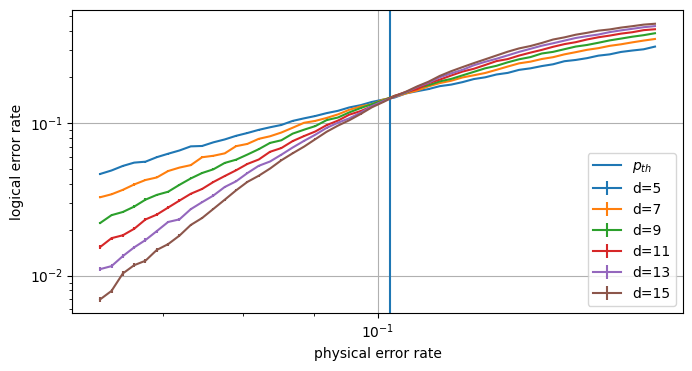

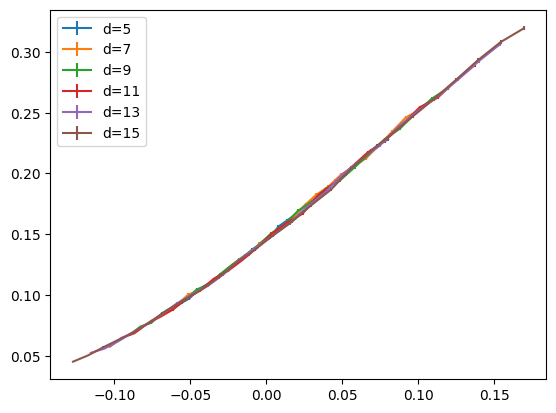

<Figure size 640x480 with 0 Axes>

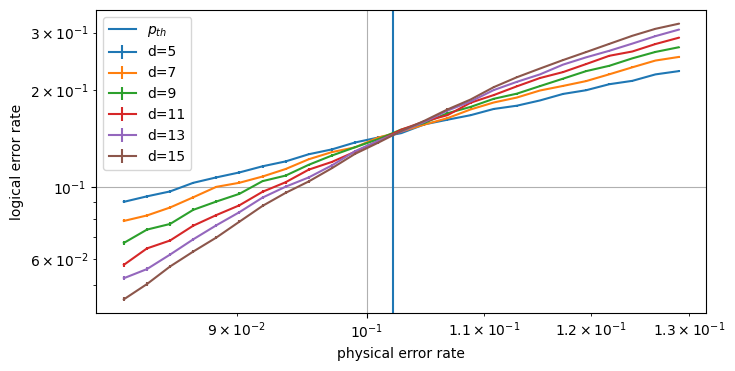

[0.1021511]
[1.46578765]


In [35]:
folder_name = r_folder_name_MWPM_Z 
g_pth = g_pth_mwpm 

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = [g_pth],
    guess_nu = [g_nu],
    min_distance= min_distance, 
    p_window =  p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_MWPM_Z= result

(array([0.08181581]),)
(array([0.12966932]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.1733716152834675
             x: [ 1.033e-01  6.851e-01]
           nit: 31
          nfev: 61
 final_simplex: (array([[ 1.033e-01,  6.851e-01],
                       [ 1.033e-01,  6.851e-01],
                       [ 1.033e-01,  6.851e-01]]), array([ 1.173e+00,  1.173e+00,  1.173e+00]))
[0.10326455]
[0.00066169]


<Figure size 640x480 with 0 Axes>

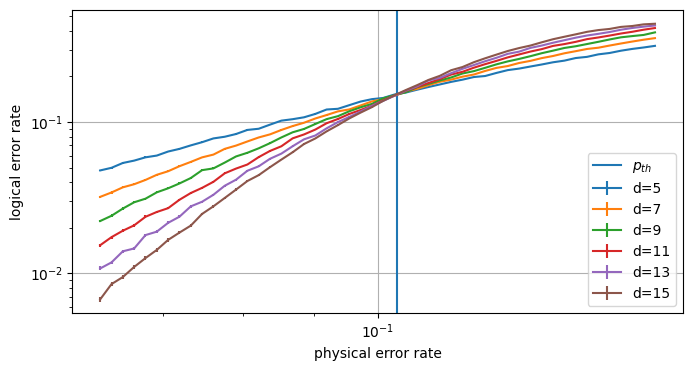

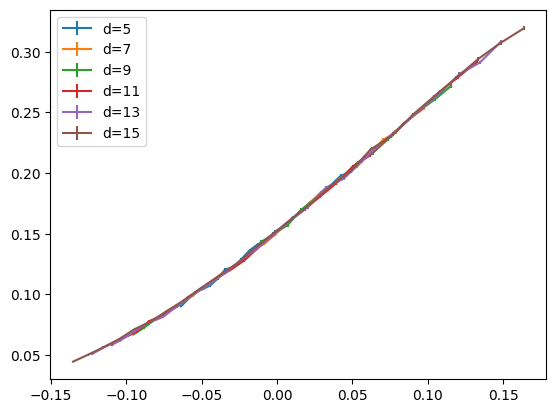

<Figure size 640x480 with 0 Axes>

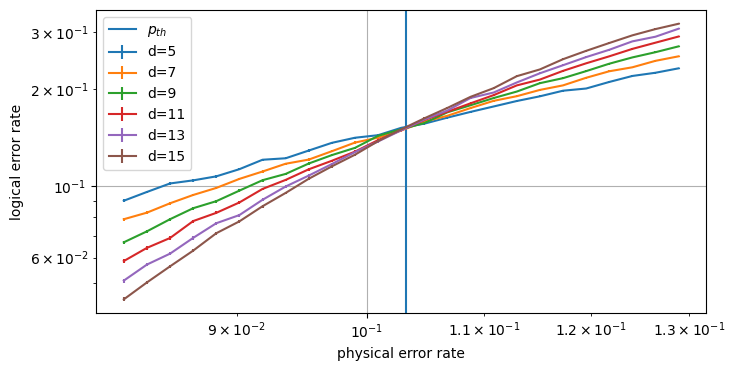

[0.10326455]
[1.45968324]


In [36]:
folder_name = r_folder_name_MWPM_X 
g_pth = g_pth_mwpm 

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = [g_pth],
    guess_nu = [g_nu],
    min_distance= min_distance, 
    p_window =  p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_MWPM_X = result

## Thresholds Results (1 round flip noise)

In [37]:
# collection of all threshold:
results = [results_ML_Z, results_ML_X, results_MWPM_Z, results_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]
literature = [lit_p_th_ml] * 2 + [lit_p_th_mwpm] * 2

for i in range(len(names)):
    print(f"For {names[i]}: threshold = {results[i]["p_th"][0]*10**2:.3f} +- {results[i]["err_p_th"][0]*10**2:.3f} %(literatur: {literature[i]*10**2:.3f}%)")



For ML Z: threshold = 10.837 +- 0.084 %(literatur: 10.940%)
For ML X: threshold = 10.748 +- 0.357 %(literatur: 10.940%)
For MWPM Z: threshold = 10.215 +- 0.080 %(literatur: 10.310%)
For MWPM X: threshold = 10.326 +- 0.066 %(literatur: 10.310%)


Results fit to expectation MWPM threshold is lower than ML threshold.

Both lay within range of the literature (Scale up to get smaller eroors)

## Varying parameters

In [38]:


# as collections
folder_names = [r_folder_name_ML_Z, r_folder_name_ML_X, r_folder_name_MWPM_Z, r_folder_name_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]

g_pths = [g_pth_ml] *2  + [g_pth_mwpm]*2

g_nus = [g_nu] * 4

In [ ]:
# Varying distance
min_distances = [5,7,9]
window_distance = 2*3 

p_th_varied = np.zeros((len(min_distances), len(folder_names)))
err_p_th_varied = np.zeros((len(min_distances), len(folder_names)))
nu_fit_varied = np.zeros((len(min_distances), len(folder_names))) 

for j in range(len(min_distances)):
    for i in range(len(folder_names)):
        print(f"min_d: {min_distances[j]}, max_d: {min_distances[j]+window_distance}")
        result = analysis_pipeline(
            folder_name = folder_names[i],
            guess_pth = [g_pths[i]],
            guess_nu = [g_nus[i]],
            min_distance= [min_distances[j]], 
            max_distance=[min_distances[j]+window_distance],
            p_window= p_window,
            plots=False,
            )

        p_th_varied[j,i] =  result["p_th"][0]
        err_p_th_varied[j,i] =  result["err_p_th"][0]
        nu_fit_varied[j,i] = result["nu_fit"][0]

min_d: 5, max_d: 11
(array([0.08578745]),)
(array([0.13596394]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.8233532358871455
             x: [ 1.078e-01  6.648e-01]
           nit: 50
          nfev: 101
 final_simplex: (array([[ 1.078e-01,  6.648e-01],
                       [ 1.078e-01,  6.648e-01],
                       [ 1.078e-01,  6.648e-01]]), array([ 8.234e-01,  8.234e-01,  8.234e-01]))
[0.10783768]
[0.00128755]
min_d: 5, max_d: 11
(array([0.08578745]),)
(array([0.13596394]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.7191417653690845
             x: [ 1.089e-01  6.728e-01]
           nit: 56
          nfev: 106
 final_simplex: (array([[ 1.089e-01,  6.728e-01],
                       [ 1.089e-01,  6.728e-01],
                       [ 1.089e-01,  6.728e-01]]), array([ 7.191e-01,  7.191e-01,  7.191e-01]))
[0.10885425]
[0.00452895]
min_d: 5, 

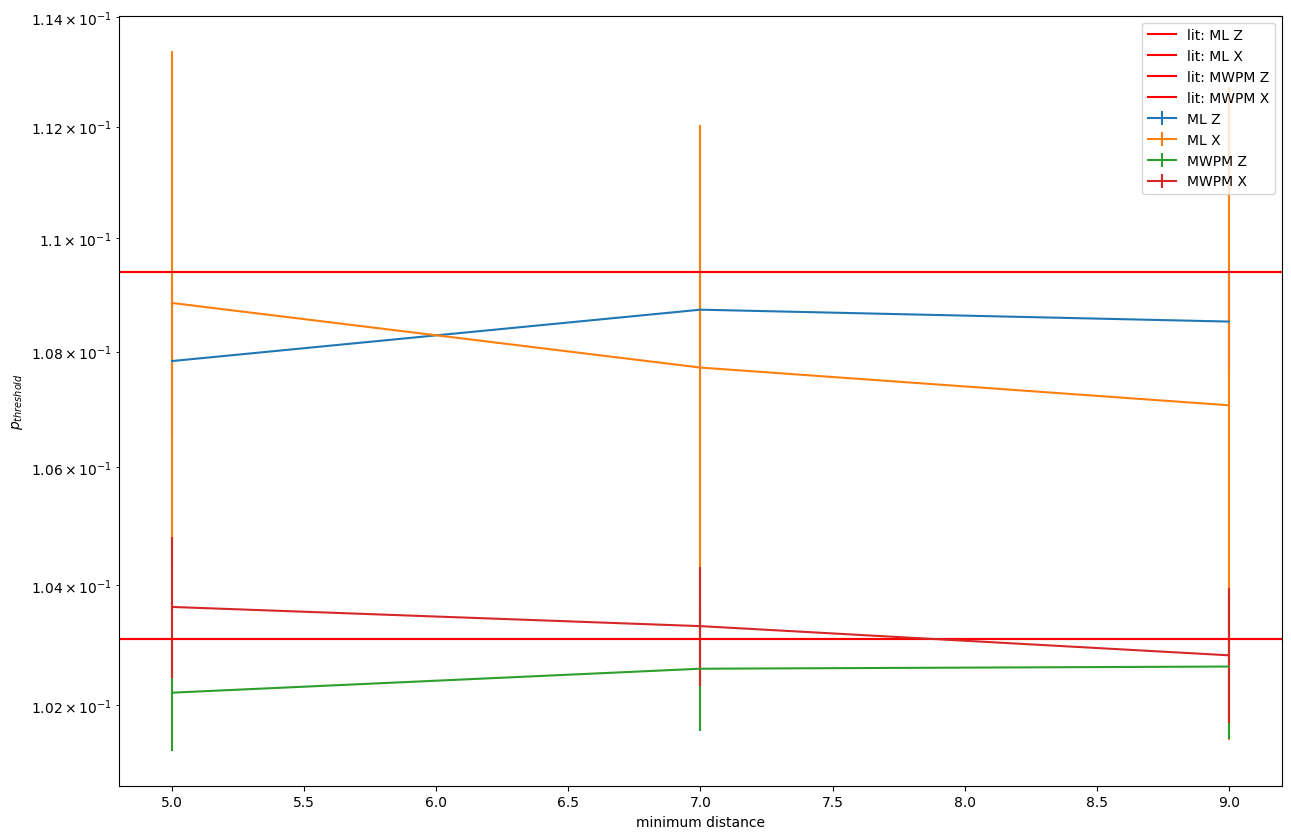

In [42]:
plt.figure(figsize=(15,10))
plt.xlabel("minimum distance")
for i in range(len(folder_names)):
    if i == 1:
        pass
        # continue
    plt.errorbar(min_distances,p_th_varied[:,i], yerr=err_p_th_varied[:,i],label=names[i])
    plt.axhline(literature[i], label="lit: "+ names[i], color= "red" )
plt.ylabel("$p_{threshold}$")
plt.yscale("log")
plt.legend()
plt.show()